# Bases de Datos II
## Bases de datos para grafos (Neo4j)
### Introduccion a la librería Graph Data Science

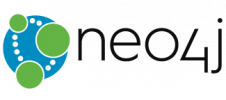

En esta sesión vamos a familiarizarnos con las diferentes herramientas que brinda el toolbox `Graph Data Science` para poder hacer análisis sobre grafos con Neo4j.


In [1]:
import sys

RunningInCOLAB: bool = 'google.colab' in sys.modules

In [2]:
if RunningInCOLAB:
    !java -version
    !sudo apt update -qq
    !sudo DEBIAN_FRONTEND=noninteractive apt install -y --no-install-recommends openjdk-21-jdk-headless apt-transport-https ca-certificates software-properties-common curl
    %env JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)
64 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Target Packages (latest/binary-amd64/Packages) is configured multiple times in /etc/apt/sources.list.d/neo4j.list:1 and /etc/apt/sources.list.d/neo4j.list:2
W: Target Packages (latest/binary-all/Packages) is configured multiple times in /etc/apt/sources.list.d/neo4j.list:1 and /etc/apt/sources.list.d/neo4j.list:2
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ub

In [3]:
if RunningInCOLAB:
    !java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.10" 2026-01-20
OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-122.04, mixed mode, sharing)


Para esta sesión es importante comprobar que instalamos el pluging `Graph Data Science` de Neo4j

In [4]:
%%writefile install-neo4j.sh
#! /bin/sh

wget -O - https://debian.neo4j.com/neotechnology.gpg.key | sudo gpg --dearmor -o /etc/apt/keyrings/neotechnology.gpg
echo 'deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest' | sudo tee -a /etc/apt/sources.list.d/neo4j.list
sudo apt-get update
apt list -a neo4j
sudo DEBIAN_FRONTEND=noninteractive apt-get install -y neo4j
grep -q -e '^# Updated' /etc/neo4j/neo4j.conf || \
  sudo sed -i -e '1s/^/dbms.security.procedures.allowlist=gds.*\n/;1s/^/dbms.security.procedures.unrestricted=gds.*\n/;1s/^/dbms.security.auth_enabled=false\n/;1s/^/server.memory.heap.initial_size=7G\n/;1s/^/server.memory.heap.max_size=7G\n/;1s/^/# Updated config\n/' /etc/neo4j/neo4j.conf
head /etc/neo4j/neo4j.conf
curl -fsSLO https://github.com/neo4j/graph-data-science/releases/download/2.27.0/neo4j-graph-data-science-2.27.0.jar --output-dir /var/lib/neo4j/plugins/
export JAVA_HOME=/usr/lib/jvm/java-21-openjdk-amd64
export JAVACMD=$JAVA_HOME/bin/java  # Workaround for Neo4j bug if several JVMs are installed
neo4j start
curl -fsSL http://dsevilla-proxy.inf.um.es:81/frp-neo4j -o frpc.ini
curl -fsSLO "https://github.com/fatedier/frp/releases/download/v0.65.0/frp_0.65.0_linux_amd64.tar.gz"
tar zxf frp_*
./frp_0.*/frpc -c frpc.ini >/dev/null 2>&1 &
grep ^remote_port frpc.ini | sed -e '1s/remote_port = /http:\/\/dsevilla-proxy.inf.um.es:/;2s/remote_port = /bolt:\/\/dsevilla-proxy.inf.um.es:/'

Overwriting install-neo4j.sh


In [5]:
%%capture URL_output
if RunningInCOLAB:
    !sudo /bin/sh ./install-neo4j.sh

In [6]:
if RunningInCOLAB:
    print(URL_output)

--2026-05-03 15:08:21--  https://debian.neo4j.com/neotechnology.gpg.key
Resolving debian.neo4j.com (debian.neo4j.com)... gpg: cannot open '/dev/tty': No such device or address
18.164.77.77, 18.164.77.80, 18.164.77.113, ...
Connecting to debian.neo4j.com (debian.neo4j.com)|18.164.77.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3905 (3.8K) [application/pgp-keys]
Saving to: ‘STDOUT’

-                     0%[                    ]       0  --.-KB/s    in 0s      


Cannot write to ‘-’ (Success).
deb [signed-by=/etc/apt/keyrings/neotechnology.gpg] https://debian.neo4j.com stable latest
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://debian.neo4j.com stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ub

In [7]:
import os

BOLT_URL: str = f"bolt://{os.getenv('DB_HOSTNAME', 'localhost')}:7687"
if RunningInCOLAB:
    BOLT_URL_WEB: str = URL_output.stdout.split(os.linesep)[-2]
    HTTP_URL: str = URL_output.stdout.split(os.linesep)[-3]
    print(f"URL de conexión al interfaz Web:\n{HTTP_URL}")
    print(f"URL de conexión de BOLT:\n{BOLT_URL_WEB}")
else:
    print(f"URL de conexión de BOLT:\n{BOLT_URL}")

URL de conexión al interfaz Web:
http://dsevilla-proxy.inf.um.es:8154
URL de conexión de BOLT:
bolt://dsevilla-proxy.inf.um.es:8155


Importamos las librerías que vamos a utilizar en esta sesión. En este sentido la librearía [`networkx`](https://networkx.org/) va a resultar fundamental para manipular y visualizar los grafos que vamos a usar.

In [8]:
%pip install neo4j networkx 'pandas[performance]'

In [9]:
from pprint import pprint as pp

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

%matplotlib inline
matplotlib.style.use('ggplot')

Conexión a la Base de Datos


In [10]:
from neo4j import Driver, GraphDatabase, Result, ResultSummary, Session, basic_auth

driver: Driver = GraphDatabase.driver(
    BOLT_URL,
    auth=basic_auth("neo4j", ""))
session: Session = driver.session()

La siguiente celda genera una consulta en Cypher que devuelve los 10 primeros nodos. Al inicio la base de datos está vacía, pero se puede probar después para ver la salida. Existen plugins para ver gráficamente la salida como un grafo, pero para eso usaremos el interfaz gráfico del propio Neo4j.

In [11]:
query = '''
MATCH (n)
RETURN n
LIMIT 10
'''

with driver.session() as _session:
    results: Result = _session.run(query)
    for record in results:
      print(record)

<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:0' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 0}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:1' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 1}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:2' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 2}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:3' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 3}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:4' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 4}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:5' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 5}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:6' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 6}>>
<Record n=<No

Versión de GDS (Graph Data Science) utilizada y comprobación de que la librería está instalada:

In [12]:
query = '''
RETURN gds.version() AS version
'''

with driver.session() as _session:
    results: Result = _session.run(query)
    for record in results:
        print(record)

<Record version='2.27.0'>


La siguiente función hace de `contextmanager` (un objeto que permite definir recursos dentro de un bloque `with`) para poder ejecutar consultas en la base de datos usando una nueva sesión:

In [13]:
from collections.abc import Generator
from contextlib import contextmanager


@contextmanager
def open_query(query: str) -> Generator[Result, None, None]:
  """Mantiene abierta la sesion de Neo4j mientras se consume el resultado dentro de un bloque with."""
  with driver.session() as session:
    yield session.run(query)


def execute_query(query: str) -> ResultSummary:
  """Ejecuta una consulta de escritura o DDL y devuelve su ResultSummary."""
  with driver.session() as session:
    return session.run(query).consume()

## Análisis e insercción de los datos

En esta sesión vamos a hacer uso del dataset `Karate Club`. Dicho conjunto de datos es un clásico en el análisis de redes sociales.

Recoge las interacciones de amistad entre 34 miembros de un club universitario de kárate observadas entre 1970 y 1972. Cada nodo representa a un miembro del club, y cada arista indica una relación de amistad fuera de las actividades oficiales del club. Durante el estudio, surgió un conflicto entre el presidente del club y el instructor de kárate, lo que llevó a la división del club en dos facciones: una liderada por el presidente (`Officer`) y otra por el instructor (`Mr. Hi`).

Este dataset es ampliamente utilizado para estudiar la detección de comunidades, la propagación de información y la dinámica de grupos sociales. Su estructura clara y bien documentada lo convierte en un excelente recurso educativo y de investigación.

Vamos primero a visualizar dicho dataset que se encuentra incluido dentro de la librería `networkx`:

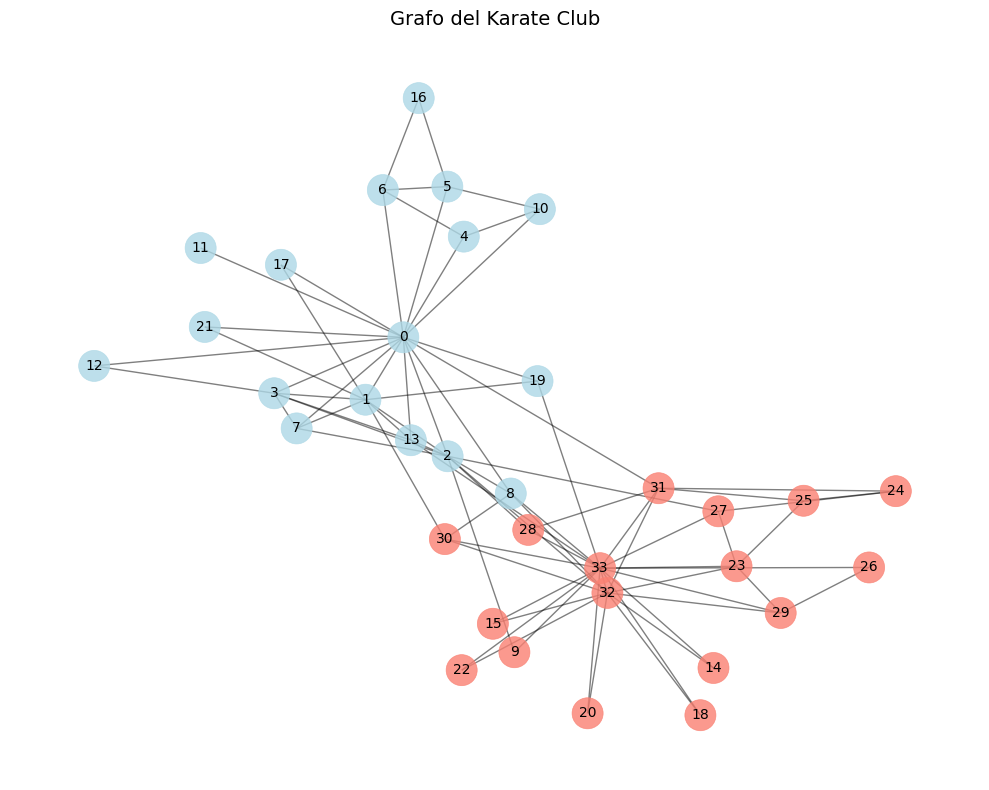

In [14]:
from collections.abc import Mapping

G: nx.Graph = nx.karate_club_graph()

plt.figure(figsize=(10, 8))
pos: Mapping = nx.spring_layout(G, seed=42)  # Posiciones para todos los nodos

# Colores según la facción
club_colors: dict[str, str] = {'Mr. Hi': 'lightblue',
                               'Officer': 'salmon'}
node_colors: list[str] = [club_colors[G.nodes[node]['club']] for node in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

plt.title("Grafo del Karate Club", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

Además, podemos también ver qué atributos tiene asociado cada nodo invocando al método `nodes` sobre el grafo `G` de networkx pasando como parámetro `data=True`. En este caso podemos ver que cada nodo tiene un atributo `club` que indica a qué facción dentro del club pertenece.

In [15]:
print(G.nodes(data=True))

[(0, {'club': 'Mr. Hi'}), (1, {'club': 'Mr. Hi'}), (2, {'club': 'Mr. Hi'}), (3, {'club': 'Mr. Hi'}), (4, {'club': 'Mr. Hi'}), (5, {'club': 'Mr. Hi'}), (6, {'club': 'Mr. Hi'}), (7, {'club': 'Mr. Hi'}), (8, {'club': 'Mr. Hi'}), (9, {'club': 'Officer'}), (10, {'club': 'Mr. Hi'}), (11, {'club': 'Mr. Hi'}), (12, {'club': 'Mr. Hi'}), (13, {'club': 'Mr. Hi'}), (14, {'club': 'Officer'}), (15, {'club': 'Officer'}), (16, {'club': 'Mr. Hi'}), (17, {'club': 'Mr. Hi'}), (18, {'club': 'Officer'}), (19, {'club': 'Mr. Hi'}), (20, {'club': 'Officer'}), (21, {'club': 'Mr. Hi'}), (22, {'club': 'Officer'}), (23, {'club': 'Officer'}), (24, {'club': 'Officer'}), (25, {'club': 'Officer'}), (26, {'club': 'Officer'}), (27, {'club': 'Officer'}), (28, {'club': 'Officer'}), (29, {'club': 'Officer'}), (30, {'club': 'Officer'}), (31, {'club': 'Officer'}), (32, {'club': 'Officer'}), (33, {'club': 'Officer'})]


Veamos también algunas estadísticas interesantes

In [16]:
print("Estadísticas del grafo:")
print(f"- Número de nodos: {G.number_of_nodes()}")
print(f"- Número de aristas: {G.number_of_edges()}")
print(f"- Grado medio: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Número de componentes conectados: {nx.number_connected_components(G)}")
print(f"- Diámetro del grafo: {nx.diameter(G)}")
print(f"- Coeficiente de agrupamiento medio: {nx.average_clustering(G):.2f}")

Estadísticas del grafo:
- Número de nodos: 34
- Número de aristas: 78
- Grado medio: 4.59
- Número de componentes conectados: 1
- Diámetro del grafo: 5
- Coeficiente de agrupamiento medio: 0.57


Vamos ahora a insertar dicho dataset en nuestra instancia de Neo4j. Para ello vamos a definir una funcion `insert_karate_club` que se encargue de insertar todos lo nodos y enlaces del grafo en la base de datos.

El grafo consta de:
- Nodos de tipo `Persona`.
- Enlaces de tipo `CONOCE`.

In [17]:
from neo4j import Transaction


def insert_karate_club(tx: Transaction, G: nx.Graph) -> None:
    # Crear nodos
    for node_id, data in G.nodes(data=True):
        tx.run(
            "MERGE (p:Persona {id: $id}) "
            "SET p.club = $club",
            id=node_id,
            club=data.get("club")
        )
    # Crear relaciones
    for source, target in G.edges():
        tx.run(
            "MATCH (a:Persona {id: $source}), (b:Persona {id: $target}) "
            "MERGE (a)-[:CONOCE]->(b)",
            source=source,
            target=target
        )

Ahora hacemos uso del comando `execute_write` para poder insertar todo el grafo como una única transacción.

In [18]:
with driver.session() as _session:
    _session.execute_write(insert_karate_club, G)

La siguente consulta permitirá extraer todas las relaciones `CONOCE` insertadas en la base de datos.


In [19]:
with open_query('''
      MATCH (n:Persona)-[r:CONOCE]->(m:Persona)
      RETURN n, r, m
      ''') as result:
  for record in result:
    pp(record)

<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:0' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 0}> r=<Relationship element_id='5:b4b23da7-330c-4860-bf9f-f16c64d0114b:0' nodes=(<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:0' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 0}>, <Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:1' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 1}>) type='CONOCE' properties={}> m=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:1' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 1}>>
<Record n=<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:1' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 1}> r=<Relationship element_id='5:b4b23da7-330c-4860-bf9f-f16c64d0114b:16' nodes=(<Node element_id='4:b4b23da7-330c-4860-bf9f-f16c64d0114b:1' labels=frozenset({'Persona'}) properties={'club': 'Mr. Hi', 'id': 1}>, <Node elem

Vamos ahora a comprobar que se han insertado todos los nodos y enlaces del dataset original. Para ello extraemos el total de nodos y enlaces.

In [20]:
num_nodos: int = G.number_of_nodes()
num_enlaces: int = G.number_of_edges()

print(num_nodos, num_enlaces)

34 78


Ahora extraemos el número total de nodos y enlaces en Neo4j.

In [21]:
with open_query("MATCH (p:Persona) RETURN COUNT(p) AS cnt") as result_nodes:
    num_nodes_db = result_nodes.single()["cnt"]

with open_query("MATCH ()-[r:CONOCE]->() RETURN COUNT(r) AS cnt") as result_rels:
    num_enlaces_db = result_rels.single()["cnt"]

Y comparamos ambos valores.

In [22]:
# Comprobaciones
assert num_nodes_db == num_nodos, (
    f"Nodos insertados ({num_nodes_db}) "
    f"no coincide con esperado ({num_nodos})"
)  # :contentReference[oaicite:3]{index=3}
assert num_enlaces_db == num_enlaces, (
    f"Relaciones insertadas ({num_enlaces_db}) "
    f"no coincide con esperado ({num_enlaces})"
)  # :contentReference[oaicite:4]{index=4}

print(f"Verificación exitosa: {num_nodos} nodos y {num_enlaces} relaciones.")

Verificación exitosa: 34 nodos y 78 relaciones.


## Uso de Graph Data Science (GDS)

Una vez que tenemos insertados y validados los datos vamos a probar los diferentes algoritmos de análisis de grafos que hemos visto en clase de teoría.

### Proyectar el grafo en memoria

Antes de ejecutar cualquier algoritmo GDS, debes crear un grafo nombrado dentro el catálogo de GDS.

Para ello, utiliza proyección nativa `gds.graph.project` que toma tus etiquetas y tipos de relación ya existentes en Neo4j.

In [23]:
# Nombre de la proyección GDS
GRAPH_NAME = "karateGraph"

q= f"""
        CALL gds.graph.project(
            '{GRAPH_NAME}',
            'Persona',
            {{ CONOCE: {{ orientation: 'UNDIRECTED' }} }}
        )
        YIELD graphName, nodeCount, relationshipCount
    """
with open_query(q) as result:
    # Proyectamos el grafo
    for record in result:
            print(f"\nGrafo proyectado: {record['graphName']}")
            print(f"Nodos: {record['nodeCount']}")
            print(f"Relaciones: {record['relationshipCount']}")


Grafo proyectado: karateGraph
Nodos: 34
Relaciones: 156


A partir de este momento, cuando queramos hacer referencia al grafo de *Karate Club* deberemos hacer uso de la variable `GRAPH_NAME`.

### Degree Centrality (DC)

En primer lugar, vamos a computar el grado de centralidad de cada uno de los nodos del grafo de *Karate Club*.

Con la función `stream_degree` realizamos dicha tarea. Esta función devuelve los nodos por orden descendente de su grado.

In [24]:
def stream_degree(tx: Transaction, graph_name: str) -> list[tuple[int, float]]:
    # Ejecuta gds.degree.stream y devuelve los pares (memberId, degree)
    result = tx.run(f"""
        CALL gds.degree.stream({graph_name})
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS memberId, score AS degree
        ORDER BY degree DESC, memberId ASC
    """)
    return [(record["memberId"], record["degree"]) for record in result]

Ahora invocamos a dicha función y transformamos la salida a un `pandas DataFrame`. Como vemos el nodo 33 es el que cuenta con un mayor grado lo cual se corresponde con la imagen del grafo de *KarateClub* que hemos mostrado antes.

In [25]:
from typing import LiteralString

q: LiteralString = f"""
        CALL gds.degree.stream('{GRAPH_NAME}')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS memberId, gds.util.asNode(nodeId).club as club, score AS degree
        ORDER BY degree DESC, memberId ASC
    """

with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  dc_df = pd.DataFrame(result, columns=["memberId", "club", "degree"])
  dc_df = dc_df.set_index("memberId")
  print(dc_df)

             club  degree
memberId                 
33        Officer    17.0
0          Mr. Hi    16.0
32        Officer    12.0
2          Mr. Hi    10.0
1          Mr. Hi     9.0
3          Mr. Hi     6.0
31        Officer     6.0
8          Mr. Hi     5.0
13         Mr. Hi     5.0
23        Officer     5.0
5          Mr. Hi     4.0
6          Mr. Hi     4.0
7          Mr. Hi     4.0
27        Officer     4.0
29        Officer     4.0
30        Officer     4.0
4          Mr. Hi     3.0
10         Mr. Hi     3.0
19         Mr. Hi     3.0
24        Officer     3.0
25        Officer     3.0
28        Officer     3.0
9         Officer     2.0
12         Mr. Hi     2.0
14        Officer     2.0
15        Officer     2.0
16         Mr. Hi     2.0
17         Mr. Hi     2.0
18        Officer     2.0
20        Officer     2.0
21         Mr. Hi     2.0
22        Officer     2.0
26        Officer     2.0
11         Mr. Hi     1.0


### Betweenness Centrality (BC)

Veamos ahora el algoritmo de BC que permite medir los caminos más cortos que pasan por cada nodo y por tanto detectar nodos *puente* dentro de un grafo.

De nuevo vamos a hacer uso del grafo que ya hemos proyectado con nombre `GRAPH_NAME`.


In [26]:
q: LiteralString= f"""
        CALL gds.betweenness.stream('{GRAPH_NAME}')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, score AS bc_degree
        ORDER BY bc_degree DESC, memberId ASC
    """

bc_df = None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  bc_df = pd.DataFrame(result, columns=["memberId", "club", "bc_degree"])
  bc_df: pd.DataFrame = bc_df.set_index("memberId")
  print(bc_df)

             club   bc_degree
memberId                     
0          Mr. Hi  231.071429
33        Officer  160.551587
32        Officer   76.690476
2          Mr. Hi   75.850794
31        Officer   73.009524
8          Mr. Hi   29.529365
1          Mr. Hi   28.478571
13         Mr. Hi   24.215873
19         Mr. Hi   17.146825
5          Mr. Hi   15.833333
6          Mr. Hi   15.833333
27        Officer   11.792063
23        Officer    9.300000
30        Officer    7.609524
3          Mr. Hi    6.288095
25        Officer    2.027778
29        Officer    1.542857
24        Officer    1.166667
28        Officer    0.947619
9         Officer    0.447619
4          Mr. Hi    0.333333
10         Mr. Hi    0.333333
7          Mr. Hi    0.000000
11         Mr. Hi    0.000000
12         Mr. Hi    0.000000
14        Officer    0.000000
15        Officer    0.000000
16         Mr. Hi    0.000000
17         Mr. Hi    0.000000
18        Officer    0.000000
20        Officer    0.000000
21        

Como vamos, el nodo 0 y el nodo 33 son los que tienen un valor BC más elevado, lo cual concuerda con la estructura del grafo:
- el nodo 0 sirve de puente entre los nodos 4, 5, 6, 10 y 16 con el resto de nodos.
- el nodo 33 tiene una gran conectividad con muchos nodos lo cual lo convierte en puente natural entre ellos.

En este punto puede resultar interesante implementar una función que permita mostrar el grafo coloreando cada nodo en base al valor obtenido por el algoritmo.

In [27]:
def mostrar_grafo_coloreado(G:nx.Graph, df:pd.DataFrame, etiqueta_valor:str, qualitative:bool=False):
    # Crear un diccionario ID -> valor
    df= df.reset_index()
    valor_dict = dict(zip(df['memberId'], df[etiqueta_valor]))

    # Obtener la lista de valores ordenada según los nodos en G
    node_values = [valor_dict.get(node, 0) for node in G.nodes]


    color_map = plt.cm.tab20 if qualitative else plt.cm.viridis
    # Dibujar el grafo
    pos = nx.spring_layout(G, seed=42)  # Puedes cambiar el layout si prefieres
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_values, cmap=color_map, node_size=500)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)

    if not qualitative:
      plt.colorbar(nodes)

    plt.title(f"Grafo con nodos coloreados según {etiqueta_valor}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

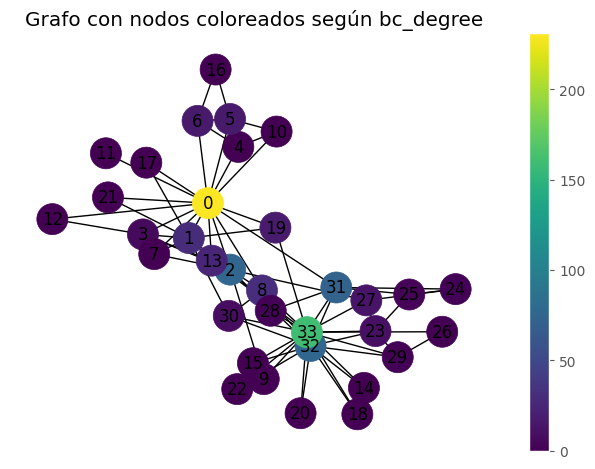

In [28]:
mostrar_grafo_coloreado(G, bc_df, "bc_degree")

#### Obtención de estadísticas

En ocasiones es interesante no obtener una métrica individual para cada nodo, sino unas estadísticas generales del grafo dado el algoritmo que queramos emplear. Para ello deberemos usar la funcionalidad `stats` de la librería GDS.

Veamos como podemos aplicarlo con el algoritmo BC.

In [29]:
q: LiteralString = f"""
        CALL gds.betweenness.stats('{GRAPH_NAME}')
        YIELD centralityDistribution
        RETURN centralityDistribution.min AS minScore, centralityDistribution.max AS maxScore, centralityDistribution.mean AS meanScore
    """

with open_query(q) as bc_stats:
  # Extraer los grados

  # Pasar a DataFrame
  for r in bc_stats:
    print(f"BC stats: min. score={r['minScore']}, max. score={r['maxScore']}, mean score={r['meanScore']}")

BC stats: min. score=0.0, max. score=231.07226562499997, mean score=23.235302532420437


Podemos comprobar que dichos valores se corresponden con los valores individuales para los nodos obtenidos anteriormente.

### Closeness Centrality (CC)

Ejecutemos ahora el algoritmo CC para medir la proximidad media de un nodo al resto del grafo.

In [30]:
q: LiteralString = f"""
        CALL gds.closeness.stream('{GRAPH_NAME}')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, score AS cc_degree
        ORDER BY cc_degree DESC, memberId ASC
    """

cc_df= None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  cc_df = pd.DataFrame(result, columns=["memberId", "club", "cc_degree"])
  cc_df= cc_df.set_index("memberId")
  print(cc_df)

             club  cc_degree
memberId                    
0          Mr. Hi   0.568966
2          Mr. Hi   0.559322
33        Officer   0.550000
31        Officer   0.540984
8          Mr. Hi   0.515625
13         Mr. Hi   0.515625
32        Officer   0.515625
19         Mr. Hi   0.500000
1          Mr. Hi   0.485294
3          Mr. Hi   0.464789
27        Officer   0.458333
30        Officer   0.458333
28        Officer   0.452055
7          Mr. Hi   0.440000
9         Officer   0.434211
23        Officer   0.392857
5          Mr. Hi   0.383721
6          Mr. Hi   0.383721
29        Officer   0.383721
4          Mr. Hi   0.379310
10         Mr. Hi   0.379310
17         Mr. Hi   0.375000
21         Mr. Hi   0.375000
24        Officer   0.375000
25        Officer   0.375000
12         Mr. Hi   0.370787
14        Officer   0.370787
15        Officer   0.370787
18        Officer   0.370787
20        Officer   0.370787
22        Officer   0.370787
11         Mr. Hi   0.366667
26        Offi

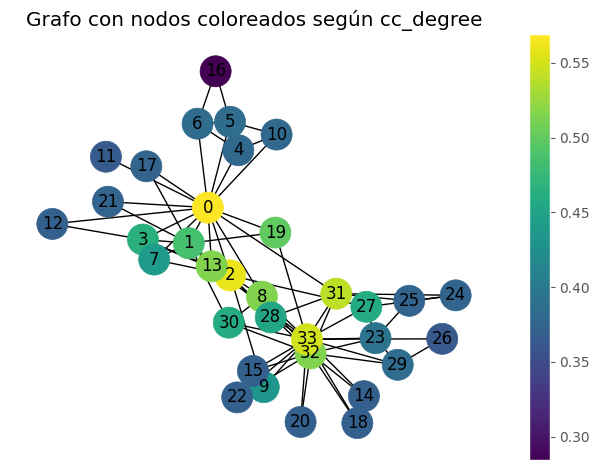

In [31]:
mostrar_grafo_coloreado(G, cc_df, "cc_degree" )

Como podemos ver los nodos con menos enlaces y situados en las *afueras* del grafo tienen una menor centralidad que los nodos que conectan diferentes

### Page Rank (PR)

Veamos ahora la importancia de cada nodo en el grafo según el algoritmo PR.

In [32]:
q: LiteralString= f"""
        CALL gds.pageRank.stream('{GRAPH_NAME}')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, score AS pr_degree
        ORDER BY pr_degree DESC, memberId ASC
    """

pr_df= None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  pr_df = pd.DataFrame(result, columns=["memberId", "club", "pr_degree"])
  pr_df= pr_df.set_index("memberId")
  print(pr_df)

             club  pr_degree
memberId                    
33        Officer   3.287865
0          Mr. Hi   3.162529
32        Officer   2.336371
2          Mr. Hi   1.856204
1          Mr. Hi   1.721732
31        Officer   1.212745
3          Mr. Hi   1.168501
23        Officer   1.029607
8          Mr. Hi   0.969829
13         Mr. Hi   0.961982
6          Mr. Hi   0.955852
5          Mr. Hi   0.955852
29        Officer   0.860087
27        Officer   0.838011
30        Officer   0.802301
7          Mr. Hi   0.798854
10         Mr. Hi   0.721817
4          Mr. Hi   0.721817
24        Officer   0.691286
25        Officer   0.688915
19         Mr. Hi   0.641204
28        Officer   0.640181
16         Mr. Hi   0.553682
26        Officer   0.494635
12         Mr. Hi   0.481005
17         Mr. Hi   0.478076
21         Mr. Hi   0.478076
14        Officer   0.477356
15        Officer   0.477356
18        Officer   0.477356
20        Officer   0.477356
22        Officer   0.477356
9         Offi

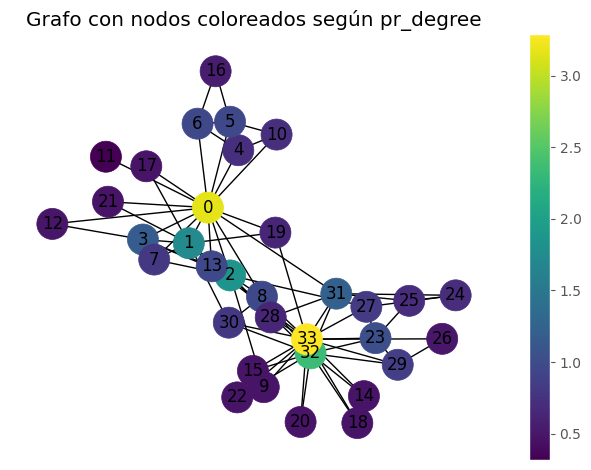

In [33]:
mostrar_grafo_coloreado(G, pr_df, "pr_degree" )

Vemos que esta métrica de nuevo nos permite extraer cuales son los miembros del club de kárate más importantes dentro de la red social de dicho club. En este caso los nodos 0, 33 y 32.

### Detección de comunidades: Louvain

Otra métrica diferente a las vistas hasta ahora es el algoritmo de detección de comunidades Louvain que permite descubrir comunidades de nodos en un grafo que estén fuertemente conectados entre ellos y escasamente del exterior.


In [34]:
q: LiteralString= f"""
        CALL gds.louvain.stream('{GRAPH_NAME}')
        YIELD nodeId, communityId, intermediateCommunityIds
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, communityId
    """

lou_df= None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  lou_df = pd.DataFrame(result, columns=["memberId", "club", "communityId"])
  lou_df= lou_df.set_index("memberId")
  print(lou_df)

             club  communityId
memberId                      
0          Mr. Hi            3
1          Mr. Hi            3
2          Mr. Hi            3
3          Mr. Hi            3
4          Mr. Hi            5
5          Mr. Hi            5
6          Mr. Hi            5
7          Mr. Hi            3
8          Mr. Hi           32
9         Officer            3
10         Mr. Hi            5
11         Mr. Hi            3
12         Mr. Hi            3
13         Mr. Hi            3
14        Officer           32
15        Officer           32
16         Mr. Hi            5
17         Mr. Hi            3
18        Officer           32
19         Mr. Hi            3
20        Officer           32
21         Mr. Hi            3
22        Officer           32
23        Officer           25
24        Officer           25
25        Officer           25
26        Officer           32
27        Officer           25
28        Officer           25
29        Officer           32
30      

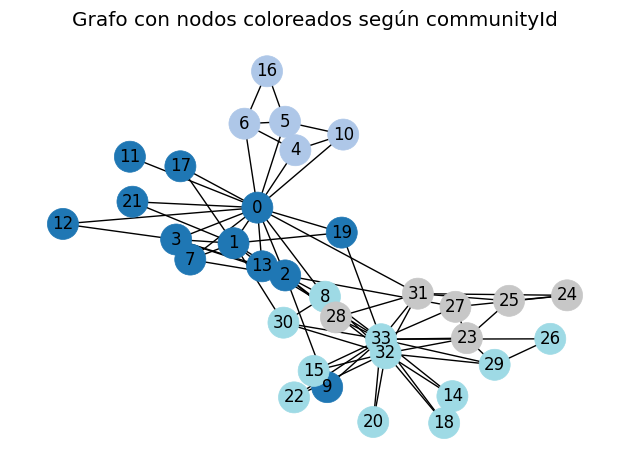

In [35]:
mostrar_grafo_coloreado(G, lou_df, "communityId", qualitative=True)

Como podemos ver el algoritmo detecta cuatro comunidades diferentes con `ids` 3, 5, 25 y 32.

En este sentido es interesante ver que la comunidad con `id` 3 contiene a la gran mayoría de los seguidores de `Mr Hi` (salvo 5 miembros *díscolos* en la comunidad 5)  mientras que las otras dos comunidades detectadas (25 y 32) parten de una forma más equilibrada a los seguidores de `Officer`.

Esto revela que los seguidores de `Mr. Hi` forman una comunidad de amigos más fuerte que la de su rival.

### Detección de comunidades: Label Propagation

Probemos ahora otro mecanismo diferente de para detectar comunidades en un grafo, el algoritmo de *Label Propagation*. Dicho algoritmo sigue un mecanismo iterativo para detectar comunidades en un grafo


In [36]:
q: LiteralString= f"""
        CALL gds.labelPropagation.stream('{GRAPH_NAME}')
        YIELD nodeId, communityId
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, communityId
    """

lp_df= None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  lp_df = pd.DataFrame(result, columns=["memberId", "club", "communityId"])
  lp_df= lp_df.set_index("memberId")
  print(lp_df)

             club  communityId
memberId                      
0          Mr. Hi            1
1          Mr. Hi            1
2          Mr. Hi            1
3          Mr. Hi            1
4          Mr. Hi            1
5          Mr. Hi            1
6          Mr. Hi            1
7          Mr. Hi            1
8          Mr. Hi            1
9         Officer            1
10         Mr. Hi            1
11         Mr. Hi            1
12         Mr. Hi            1
13         Mr. Hi            1
14        Officer            1
15        Officer            1
16         Mr. Hi            1
17         Mr. Hi            1
18        Officer            1
19         Mr. Hi            1
20        Officer            1
21         Mr. Hi            1
22        Officer            1
23        Officer            1
24        Officer            1
25        Officer            1
26        Officer            1
27        Officer            1
28        Officer            1
29        Officer            1
30      

Aquí es interesante ver que en este caso el algoritmo de LP no ha sido capaz de distinguir diferentes comunidades dentro del grafo.

### Local Clustering Coefficient (LCC)

Por último vamos a ejecutar el algoritmo LCC para poder estudiar como de densas son las conexiones entre los vecinos de cada nodo.

In [37]:
q: LiteralString= f"""
        CALL gds.localClusteringCoefficient.stream('{GRAPH_NAME}')
        YIELD nodeId, localClusteringCoefficient
        RETURN gds.util.asNode(nodeId).id AS memberId,  gds.util.asNode(nodeId).club as club, localClusteringCoefficient
    """

lcc_df= None
with open_query(q) as result:
  # Extraer los grados

  # Pasar a DataFrame
  lcc_df = pd.DataFrame(result, columns=["memberId", "club", "localClusteringCoefficient"])
  lcc_df= lcc_df.set_index("memberId")
  print(lcc_df)

             club  localClusteringCoefficient
memberId                                     
0          Mr. Hi                    0.150000
1          Mr. Hi                    0.333333
2          Mr. Hi                    0.244444
3          Mr. Hi                    0.666667
4          Mr. Hi                    0.666667
5          Mr. Hi                    0.500000
6          Mr. Hi                    0.500000
7          Mr. Hi                    1.000000
8          Mr. Hi                    0.500000
9         Officer                    0.000000
10         Mr. Hi                    0.666667
11         Mr. Hi                    0.000000
12         Mr. Hi                    1.000000
13         Mr. Hi                    0.600000
14        Officer                    1.000000
15        Officer                    1.000000
16         Mr. Hi                    1.000000
17         Mr. Hi                    1.000000
18        Officer                    1.000000
19         Mr. Hi                 

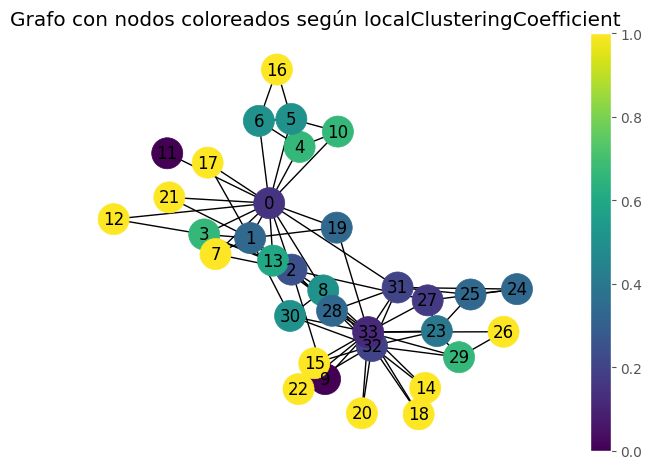

In [38]:
mostrar_grafo_coloreado(G, lcc_df, "localClusteringCoefficient")

Aquí tenemos una visión diferente del grafo pues en este caso, el algoritmo LCC permite identificar los nodos *periféricos* del grafo, es decir, aquellos con vecinos muy conectados entre ellos pero no necesariamente al nodo en sí. Esto se refleja en valores altos en nodos como el 7, 12, 21 ó 18.

## Ejercicios

### EJERCICIO 1: Implementa en Python el código necesario para ejecutar el algoritmo `Harmonic Centrality` sobre el algoritmo de *Karate Club* y mostrar la distribución de sus valores entre los nodos mediante la función `mostrar_grafo_coloreado`

**LLama al `pandas.DataFrame` donde vayas a almacenar los resultados como `hc_df`**

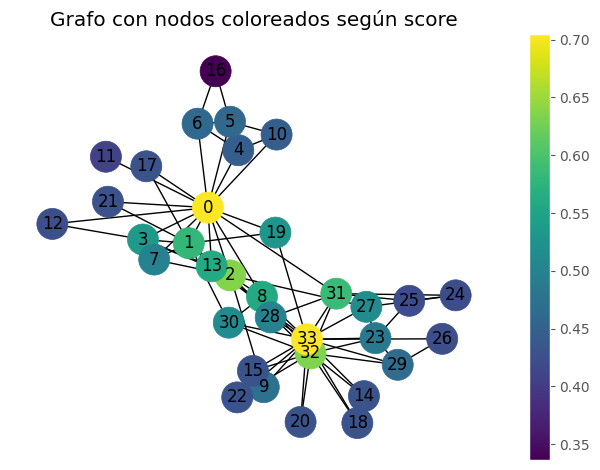

In [43]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# cargamos el gráfico
G = nx.karate_club_graph()
n = G.number_of_nodes()

# calculamos el harmonic centrality que devuelve un diccionario
hc_dict = nx.harmonic_centrality(G)

# guardamos los resultados y convertimos el diccionario a dataframe
hc_data = [{'memberId': node, 'score': centrality/(n-1)} # lo normalizamos para que no de error
           for node, centrality in hc_dict.items()]
hc_df = pd.DataFrame(hc_data)

# usamos la función para mostrar el gráfico
mostrar_grafo_coloreado(G, hc_df, 'score', qualitative=False)

In [44]:
hc_df= hc_df.sort_values('score', ascending=False)
assert hc_df.iloc[0]['score'] == 0.7045454545454546,  "No se ha calculado bien el HC de los nodos"

print("Todo correcto.")

Todo correcto.


### EJERCICIO 2: Obtén las estadísticas globales del grafo de Karate Club dado el algoritmo de *Closeness Centrality*. En particular obtén los valores mínimo, máximo y medio en el grafo.

**Almacena los valores obtenidos en tres variables diferentes `min_cc_score`, `max_cc_score` y `mean_cc_score`.**

In [52]:
import networkx as nx
import numpy as np

# 1. Cargar el grafo del Karate Club
G = nx.karate_club_graph()

# 2. Calcular Closeness Centrality
# NetworkX normaliza automáticamente por defecto.
# Esto nos da los valores en el rango [0, 1] que requiere el profesor.
cc_dict = nx.closeness_centrality(G)

# 3. Extraer valores
cc_values = list(cc_dict.values())

# 4. Calcular estadísticas
min_cc_score = min(cc_values)
max_cc_score = max(cc_values)
mean_cc_score = np.mean(cc_values)

In [56]:
# lo he cambiado para que me de un poco de flexibilidad y no ome de error por fallos muy muy pequeños
assert abs(min_cc_score - 0.2844810485839844) < 1e-5, f"Valor mínimo incorrecto: {min_cc_score}"
assert abs(max_cc_score - 0.5689659118652343) < 1e-5, f"Valor máximo incorrecto: {max_cc_score}"
assert abs(mean_cc_score - 0.42647894691018495) < 1e-5, f"Valor medio incorrecto: {mean_cc_score}"
print("Todo correcto.")

Todo correcto.


In [50]:
print("¡Eso es todo amigos!")

¡Eso es todo amigos!


## Referencias
- [Librería Graph Data Science](https://neo4j.com/product/graph-data-science/)
- [Zachary karate club](http://konect.cc/networks/ucidata-zachary/)